In [6]:
!pip install ultralytics

In [7]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt

In [13]:
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'dataset', 'Project5_Ag_Crop and weed detection.zip', 'sample_data']


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os

print(os.getcwd())

/content


In [17]:
import os

for root, dirs, files in os.walk("/content"):
    if "agri_data" in dirs:
        print(os.path.join(root, "agri_data"))

In [19]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.06.04
/content/.ipynb_checkpoints
/content/dataset
/content/dataset/Project5_Ag_Crop and weed detection
/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/UPSKILL INTERN
/content/drive/MyDrive/Classroom
/content/drive/MyDrive/Classroom/I - AI&DS (2024 - 2028) "A"   Problem Solving using C
/content/drive/MyDrive/Classroom/I year AI&DS A
/content/drive/MyDrive/Classroom/I-AIDS-A_(24-28)_Sem-II
/content/drive/MyDrive/Classroom/II AIDS A&B DATA EXPLORATION AND VISUALIZATION
/content/drive/MyDrive/Classroom/II AI & DS 'A' & 'B' Section
/content/drive/MyDrive/Classroom/II year 2024-2028 Batch A section
/content/drive/MyDrive/Classroom/u23ad404 foundations of datascienceand analytics
/content/drive/MyDrive/Classroom/II AIDS A
/content/drive/MyDrive/Classroom/2025-2026 II AIDS A
/content/drive/MyDrive/

In [21]:
import os

print(os.listdir("/content/dataset/Project5_Ag_Crop and weed detection"))

['~$oject1.docx', 'Project5_Ag_Crop and weed detection.docx', 'Project5_Ag_Crop and weed detection.zip']


In [22]:
import zipfile

inner_zip = "/content/dataset/Project5_Ag_Crop and weed detection/Project5_Ag_Crop and weed detection.zip"

extract_to = "/content/project5"

with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("Done!")

Done!


In [23]:
import os

print(os.listdir("/content/project5"))

['agri_data', 'classes.txt']


In [24]:
import os

print(os.listdir("/content/project5/agri_data"))

['data']


In [25]:
import os

print(os.listdir("/content/project5/agri_data/data")[:10])

['agri_0_6469.txt', 'agri_0_5587.jpeg', 'agri_0_8913.txt', 'agri_0_2513.jpeg', 'agri_0_4455.txt', 'agri_0_2906.txt', 'agri_0_3807.jpeg', 'agri_0_4488.jpeg', 'agri_0_8046.txt', 'agri_0_1260.txt']


In [28]:
import os

print(os.listdir("/content/project5/agri_data"))

['data']


In [29]:
import os

for root, dirs, files in os.walk("/content/project5/agri_data"):
    print(root)

/content/project5/agri_data
/content/project5/agri_data/data


In [30]:
import os

print(os.listdir("/content/project5/agri_data/data")[:20])

['agri_0_6469.txt', 'agri_0_5587.jpeg', 'agri_0_8913.txt', 'agri_0_2513.jpeg', 'agri_0_4455.txt', 'agri_0_2906.txt', 'agri_0_3807.jpeg', 'agri_0_4488.jpeg', 'agri_0_8046.txt', 'agri_0_1260.txt', 'agri_0_4016.jpeg', 'agri_0_9398.txt', 'agri_0_2082.txt', 'agri_0_9714.txt', 'agri_0_5622.jpeg', 'agri_0_6572.txt', 'agri_0_830.txt', 'agri_0_110.jpeg', 'agri_0_1722.txt', 'agri_0_6346.txt']


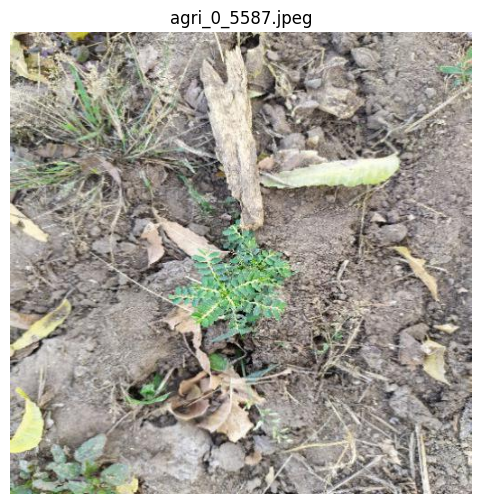

In [33]:
import os
import cv2
import matplotlib.pyplot as plt

data_path = "/content/project5/agri_data/data"

image_file = [f for f in os.listdir(data_path) if f.endswith(".jpeg")][0]

image_path = os.path.join(data_path, image_file)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(image_file)
plt.axis("off")
plt.show()

In [34]:
import os

image_file = [f for f in os.listdir(data_path) if f.endswith(".jpeg")][0]

label_file = image_file.replace(".jpeg", ".txt")

print("Image :", image_file)
print("Label :", label_file)

label_path = os.path.join(data_path, label_file)

with open(label_path, "r") as file:
    print(file.read())

Image : agri_0_5587.jpeg
Label : agri_0_5587.txt
1 0.468750 0.555664 0.285156 0.279297
1 0.213867 0.233398 0.384766 0.373047



In [35]:
with open("/content/project5/classes.txt","r") as file:
    print(file.read())

crop
weed


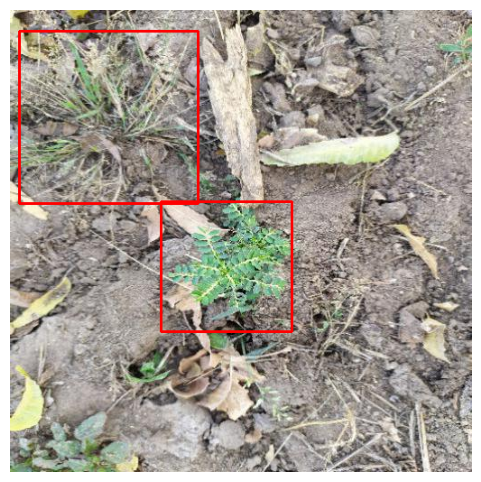

In [36]:
import cv2
import matplotlib.pyplot as plt
import os

data_path = "/content/project5/agri_data/data"

image_file = "agri_0_5587.jpeg"
label_file = "agri_0_5587.txt"

image = cv2.imread(os.path.join(data_path, image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(os.path.join(data_path, label_file), "r") as f:
    for line in f:
        cls, x, y, bw, bh = map(float, line.split())

        x = x * w
        y = y * h
        bw = bw * w
        bh = bh * h

        x1 = int(x - bw / 2)
        y1 = int(y - bh / 2)
        x2 = int(x + bw / 2)
        y2 = int(y + bh / 2)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [37]:
import cv2
import os

image = cv2.imread("/content/project5/agri_data/data/agri_0_5587.jpeg")

print(image.shape)

(512, 512, 3)


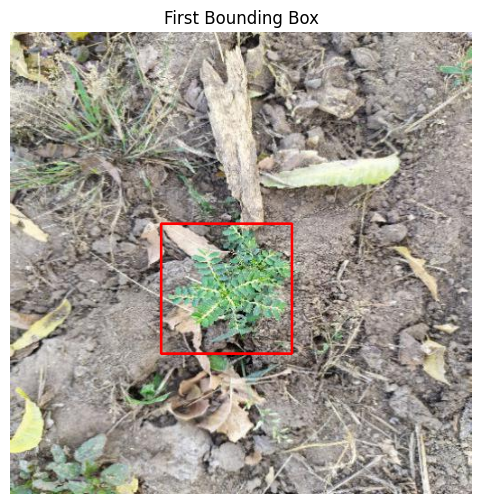

In [38]:
import cv2
import matplotlib.pyplot as plt
import os

data_path = "/content/project5/agri_data/data"

image_file = "agri_0_5587.jpeg"
label_file = "agri_0_5587.txt"

image = cv2.imread(os.path.join(data_path, image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width, _ = image.shape

with open(os.path.join(data_path, label_file), "r") as file:

    line = file.readline()

    cls, x, y, w, h = map(float, line.split())

    x = x * width
    y = y * height
    w = w * width
    h = h * height

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("First Bounding Box")
plt.axis("off")
plt.show()

In [39]:
import os

data_path = "/content/project5/agri_data/data"

files = os.listdir(data_path)

image_count = 0
label_count = 0

for file in files:
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        image_count += 1
    elif file.endswith(".txt"):
        label_count += 1

print("Total Images :", image_count)
print("Total Labels :", label_count)

Total Images : 1300
Total Labels : 1300


In [40]:
import os

crop = 0
weed = 0

for file in os.listdir(data_path):
    if file.endswith(".txt"):
        with open(os.path.join(data_path, file), "r") as f:
            for line in f:
                class_id = int(line.split()[0])

                if class_id == 0:
                    crop += 1
                elif class_id == 1:
                    weed += 1

print("Crop Objects :", crop)
print("Weed Objects :", weed)

Crop Objects : 1212
Weed Objects : 860


In [41]:
import os

base_path = "/content/project5/yolo_dataset"

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("YOLO folder structure created successfully!")

YOLO folder structure created successfully!


In [42]:
import os
import random
import shutil

source_path = "/content/project5/agri_data/data"

images = [
    f for f in os.listdir(source_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.shuffle(images)

split_index = int(len(images) * 0.8)

train_images = images[:split_index]
valid_images = images[split_index:]

print("Training Images :", len(train_images))
print("Validation Images :", len(valid_images))

Training Images : 1040
Validation Images : 260


In [43]:
for image in train_images:

    shutil.copy(
        os.path.join(source_path, image),
        os.path.join(base_path, "train/images", image)
    )

    label = os.path.splitext(image)[0] + ".txt"

    shutil.copy(
        os.path.join(source_path, label),
        os.path.join(base_path, "train/labels", label)
    )

print("✅ Training dataset copied successfully!")

✅ Training dataset copied successfully!


In [44]:
for image in valid_images:

    shutil.copy(
        os.path.join(source_path, image),
        os.path.join(base_path, "valid/images", image)
    )

    label = os.path.splitext(image)[0] + ".txt"

    shutil.copy(
        os.path.join(source_path, label),
        os.path.join(base_path, "valid/labels", label)
    )

print("✅ Validation dataset copied successfully!")

✅ Validation dataset copied successfully!


In [45]:
data_yaml = """
train: /content/project5/yolo_dataset/train/images
val: /content/project5/yolo_dataset/valid/images

nc: 2

names:
  0: crop
  1: weed
"""

with open("/content/project5/yolo_dataset/data.yaml", "w") as file:
    file.write(data_yaml)

print("✅ data.yaml created successfully!")

✅ data.yaml created successfully!


In [46]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/project5/yolo_dataset/data.yaml",
    epochs=20,
    imgsz=512
)

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project5/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c8d944811f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [47]:
import os

print(os.path.exists("/content/project5/yolo_dataset/data.yaml"))

True


In [48]:
!cat /content/project5/yolo_dataset/data.yaml


train: /content/project5/yolo_dataset/train/images
val: /content/project5/yolo_dataset/valid/images

nc: 2

names:
  0: crop
  1: weed


In [49]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/project5/yolo_dataset/data.yaml",
    epochs=20,
    imgsz=512,
    batch=16
)

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project5/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

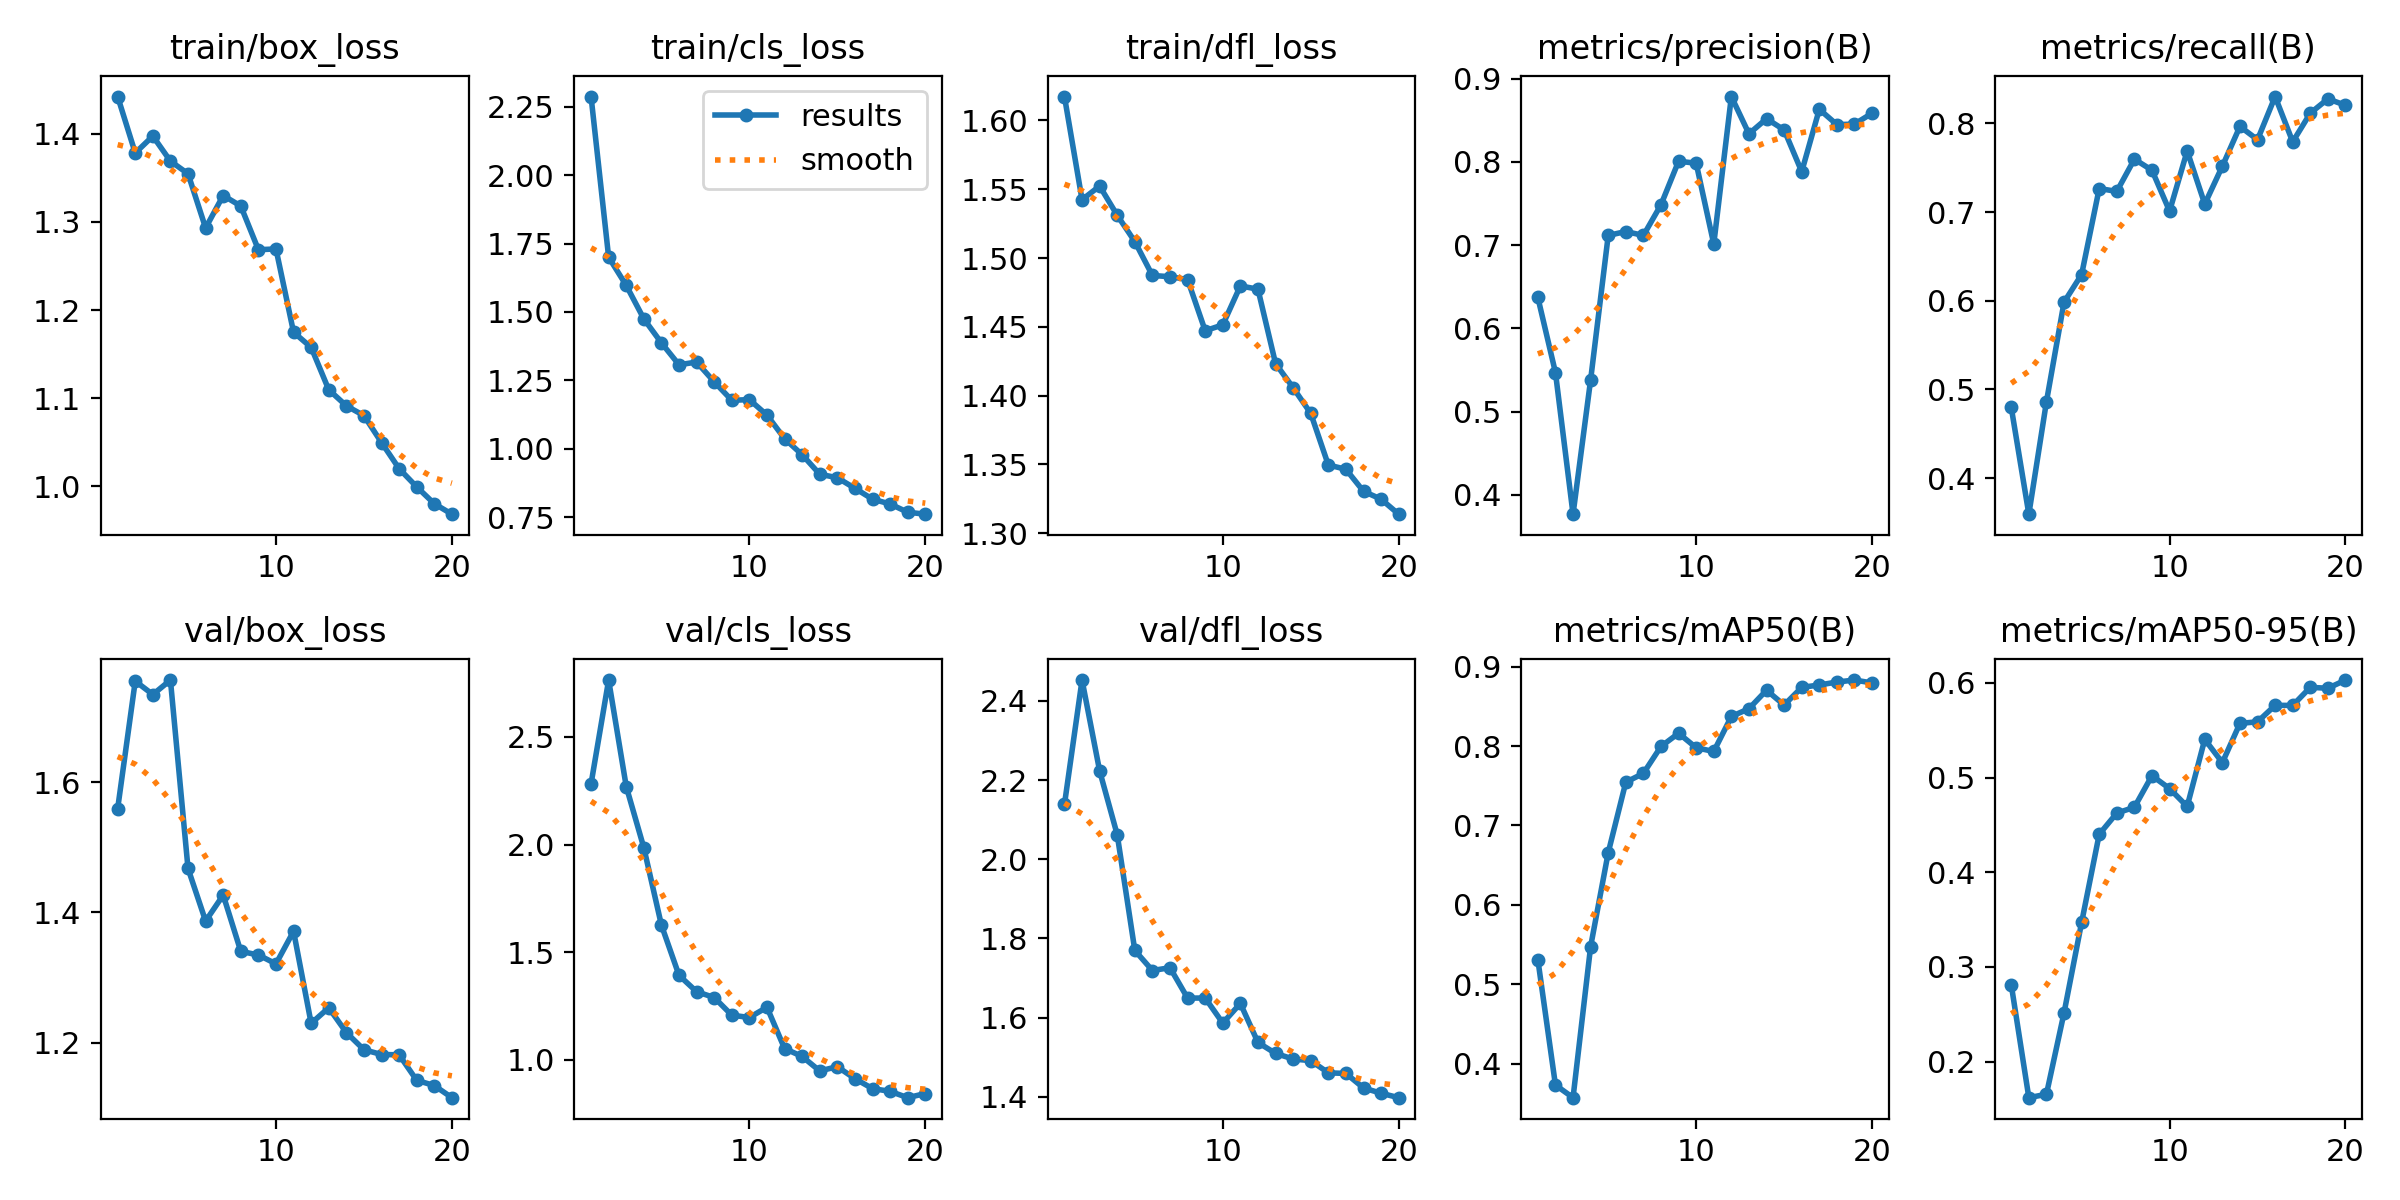

In [50]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/train-2/results.png"))

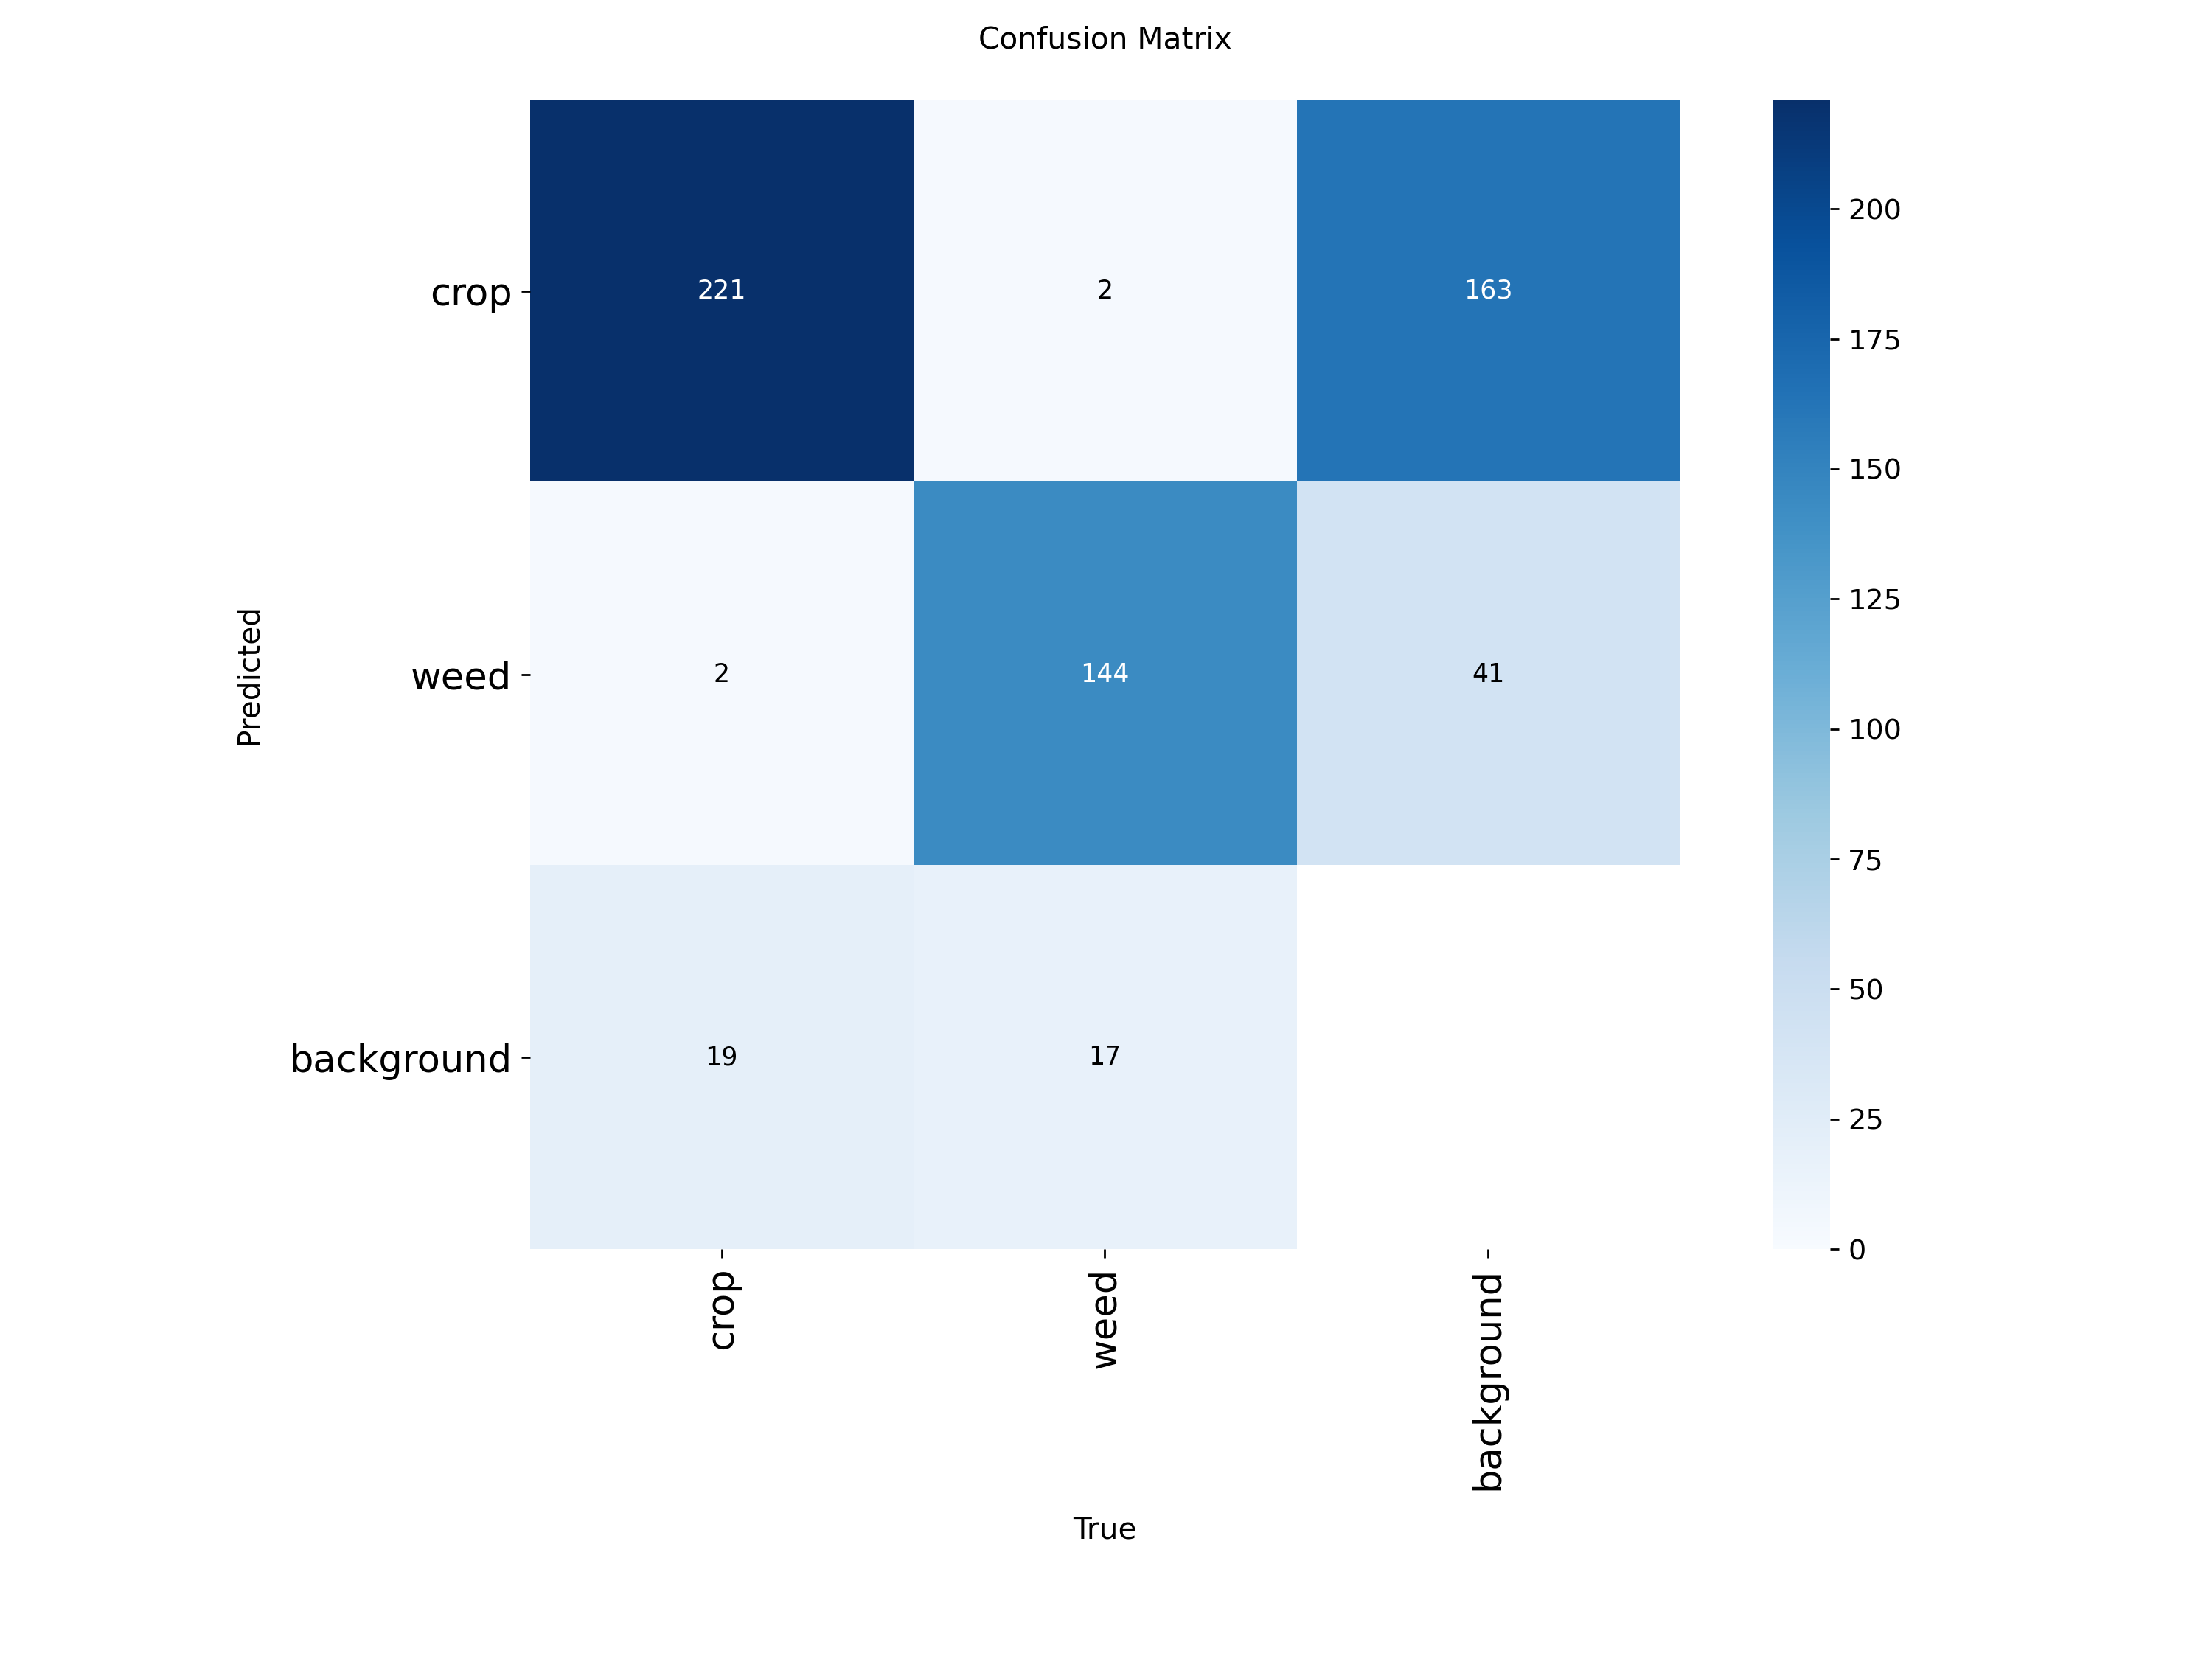

In [51]:
display(Image(filename="/content/runs/detect/train-2/confusion_matrix.png"))

In [52]:
import os

print(os.listdir("/content/runs/detect/train-2/weights"))

['last.pt', 'best.pt']


In [53]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

results = model.predict(
    source="/content/project5/agri_data/data/agri_0_5587.jpeg",
    save=True,
    conf=0.25
)


image 1/1 /content/project5/agri_data/data/agri_0_5587.jpeg: 512x512 4 weeds, 10.7ms
Speed: 1.7ms preprocess, 10.7ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict


In [56]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-2/weights/best.pt")

results = model.predict(
    source="/content/project5/agri_data/data/agri_0_5587.jpeg",
    save=True,
    conf=0.25
)


image 1/1 /content/project5/agri_data/data/agri_0_5587.jpeg: 512x512 4 weeds, 10.3ms
Speed: 2.1ms preprocess, 10.3ms inference, 2.4ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict-2


In [57]:
import os

print(os.listdir("/content/runs/detect"))

['train-2', 'predict-2', 'train', 'predict']


In [59]:
import os

print(os.listdir("/content/runs/detect/predict-2"))

['agri_0_5587.jpg']


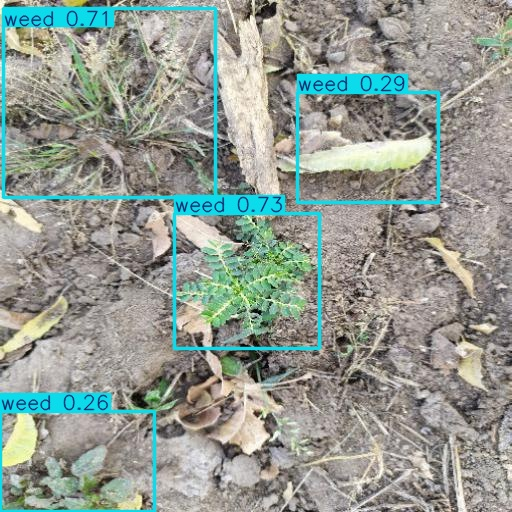

In [60]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict-2/agri_0_5587.jpg"))

In [61]:
import shutil

shutil.copy(
    "/content/runs/detect/train-2/weights/best.pt",
    "/content/drive/MyDrive/UPSKILL INTERN/Project5_best.pt"
)

print("✅ Best model saved to Google Drive")

✅ Best model saved to Google Drive
